# Covariance inspection (config 1)

Loads a config-1 aggregates H5 (electron + ion TOF, plus GMD
aggregates) and forms two quantities per GMD bin:

  * **Electron–ion covariance**:
      `Cov(D, C) = <DtC> − <D><C>ᵀ`  shape `(n_tof, n_tof_i)`

  * **Partial covariance (controlling for GMD)**:
      `Cov(D, C | G) = Cov(D, C) − Cov(D, G) · Cov(G, C) / Var(G)`

    where `G` is the per-shot scalar GMD. The correction subtracts the
    linear common-mode signal that both detectors inherit from
    pulse-energy fluctuations; what's left is the photon-energy /
    correlated-emission signature that survives intensity normalisation.

In [8]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from compute_aggregates import load_aggregates

%matplotlib inline

## Parameters

In [9]:
AGGREGATES_FILE = config.COMBINED_DIR / "test_config1_aggregates.h5"
CLIM_PERCENTILE = 99.0

## Load

In [3]:
agg = load_aggregates(AGGREGATES_FILE)
assert agg.config == 1, "This notebook expects a config-1 aggregates file."

print(f"file        : {AGGREGATES_FILE}")
print(f"config      : {agg.config}")
print(f"mode        : {agg.mode}")
print(f"n_gmd_bins  : {agg.n_gmd_bins}")
print(f"n_tof  (e)  : {agg.n_tof}    ({agg.tof_edges[0]:.0f} .. {agg.tof_edges[-1]:.0f} ns)")
print(f"n_tof_i     : {agg.n_tof_i}  ({agg.ion_tof_edges[0]:.0f} .. {agg.ion_tof_edges[-1]:.0f} ns)")
print(f"shots / bin : {agg.n_per_bin}")
print(f"G per bin   : {np.round(agg.G, 3)}")
print(f"Var(G)/bin  : {np.round(agg.var_G, 4)}")

file        : C:\Users\oga17\OneDrive - Imperial College London\Python\glycine2026\11022188\processed\combined\test_config1_aggregates.h5
config      : 1
mode        : spectral
n_gmd_bins  : 7
n_tof  (e)  : 125    (500 .. 1750 ns)
n_tof_i     : 160  (1000 .. 9000 ns)
shots / bin : [9638287 3330940 4127741 4552106 2978859  887124  109775]
G per bin   : [0.023 0.073 0.146 0.286 0.552 1.026 1.818]
Var(G)/bin  : [0.0002 0.0002 0.0008 0.0032 0.012  0.0322 0.0875]


## Compute covariances per bin

Vectorised over the GMD axis. Shapes:

    cov_DC          (n_gmd, n_tof,  n_tof_i)
    cov_DG          (n_gmd, n_tof)
    cov_GC          (n_gmd, n_tof_i)
    cov_DC_partial  (n_gmd, n_tof,  n_tof_i)

In [4]:
# Direct electron-ion covariance.
cov_DC = agg.DtC - agg.D[..., :, None] * agg.C[..., None, :]

# Covariances of each spectrum with the scalar GMD per bin.
cov_DG = agg.DtG - agg.D * agg.G[..., None]
cov_GC = agg.CtG - agg.C * agg.G[..., None]

var_G  = agg.var_G                                             # (n_gmd,)
safe_var = np.where(var_G > 0, var_G, np.nan)

# Partial: subtract the rank-1 GMD-driven correction.
correction = (cov_DG[..., :, None] * cov_GC[..., None, :]) / safe_var[..., None, None]
cov_DC_partial = cov_DC - correction

# Quick numerical summary per bin.
print(f"{'bin':>3}  {'n':>8}  {'<G>':>7}  {'Var(G)':>9}  "
      f"{'|Cov(D,C)|':>12}  {'|partial|':>12}  {'ratio':>6}")
for b in range(agg.n_gmd_bins):
    if agg.n_per_bin[b] == 0:
        continue
    cov_n      = float(np.linalg.norm(cov_DC[b]))
    cov_part_n = float(np.linalg.norm(cov_DC_partial[b]))
    print(f"{b:>3}  {int(agg.n_per_bin[b]):>8d}  "
          f"{agg.G[b]:>7.3f}  {var_G[b]:>9.3e}  "
          f"{cov_n:>12.3e}  {cov_part_n:>12.3e}  "
          f"{cov_part_n / cov_n if cov_n else float('nan'):>6.3f}")

bin         n      <G>     Var(G)    |Cov(D,C)|     |partial|   ratio
  0   9638287    0.023  1.646e-04     1.304e-01     1.270e-01   0.974
  1   3330940    0.073  2.142e-04     1.845e-01     1.827e-01   0.991
  2   4127741    0.146  8.403e-04     1.906e-01     1.900e-01   0.997
  3   4552106    0.286  3.233e-03     1.925e-01     1.922e-01   0.999
  4   2978859    0.552  1.200e-02     1.955e-01     1.954e-01   0.999
  5    887124    1.026  3.223e-02     2.001e-01     2.001e-01   1.000
  6    109775    1.818  8.748e-02     2.100e-01     2.101e-01   1.000


## Electron–ion covariance per GMD bin

Each panel: rows = eTOF bins, columns = ion-TOF bins. Diverging
colormap; the colour scale is the 99th percentile of `|cov|` per
panel so a single hot pair doesn't dominate.

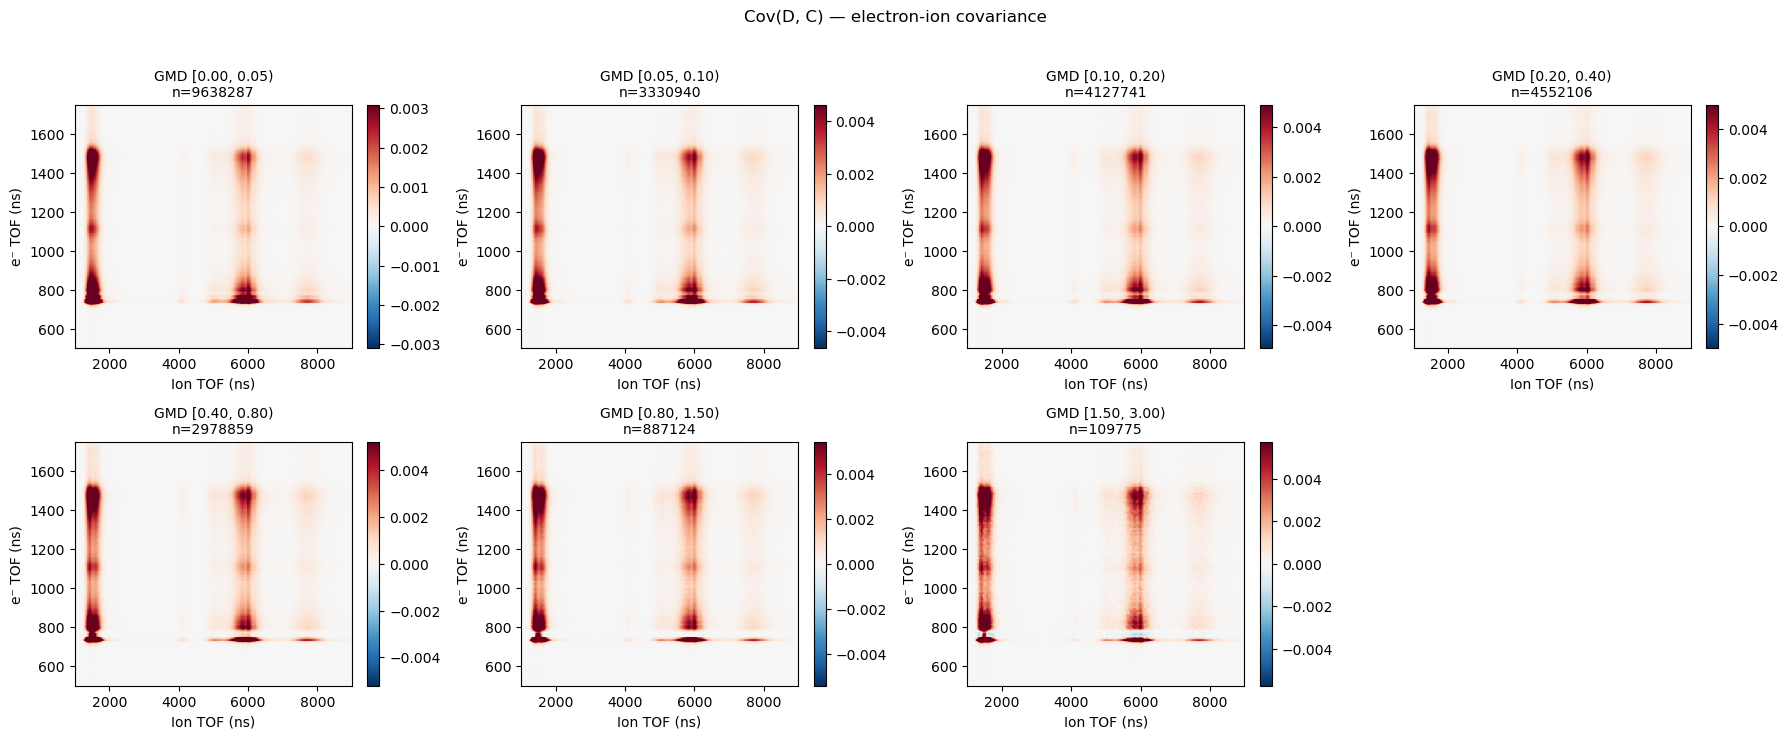

In [5]:
def _grid(n):
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    return rows, cols

def _plot_cov_grid(matrices, title):
    rows, cols = _grid(agg.n_gmd_bins)
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.6 * rows))
    axes_flat = np.atleast_1d(axes).ravel()
    extent = [agg.ion_tof_edges[0], agg.ion_tof_edges[-1],
              agg.tof_edges[0],     agg.tof_edges[-1]]
    for b in range(agg.n_gmd_bins):
        ax = axes_flat[b]
        M = matrices[b]
        if not np.isfinite(M).any():
            ax.set_title(f"bin {b} (empty)")
            ax.axis("off")
            continue
        vmax = float(np.nanpercentile(np.abs(M), CLIM_PERCENTILE)) or 1.0
        im = ax.imshow(M, origin="lower", cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
        ax.set_title(f"GMD [{agg.gmd_edges[b]:.2f}, {agg.gmd_edges[b+1]:.2f})\n"
                     f"n={int(agg.n_per_bin[b])}", fontsize=10)
        ax.set_xlabel("Ion TOF (ns)")
        ax.set_ylabel("e\u207b TOF (ns)")
        fig.colorbar(im, ax=ax, fraction=0.046)
    for ax in axes_flat[agg.n_gmd_bins:]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

_plot_cov_grid(cov_DC, "Cov(D, C) — electron-ion covariance")

## Partial covariance `Cov(D, C | G)`

Same panels, but with the GMD-driven common-mode subtracted via
`Cov(D, G) Cov(G, C)ᵀ / Var(G)`. Features that remain are not
explained by linear correlations with pulse energy.

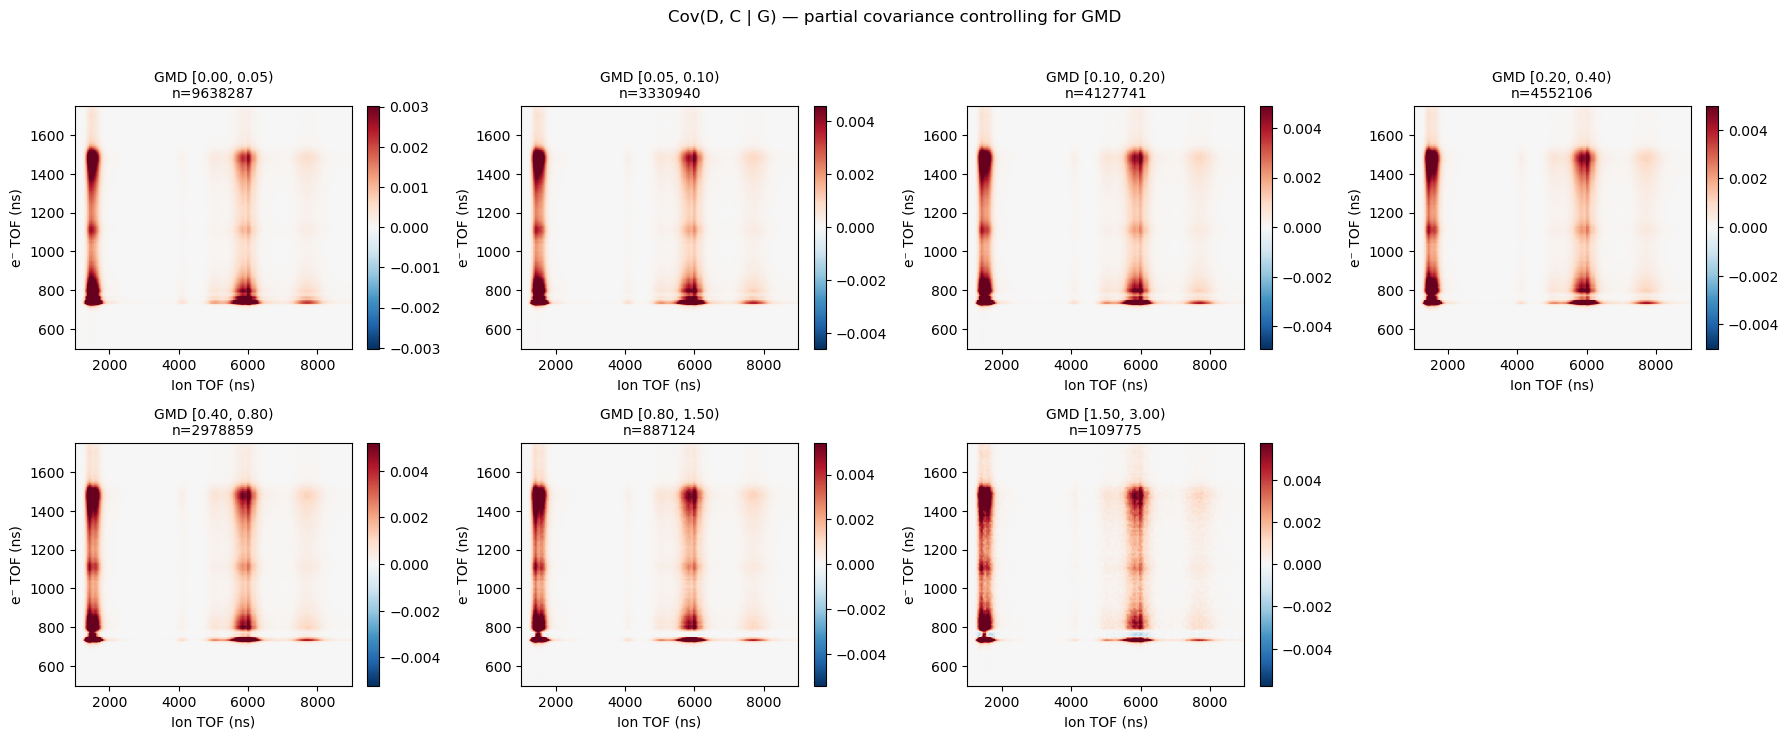

In [6]:
_plot_cov_grid(cov_DC_partial, "Cov(D, C | G) — partial covariance controlling for GMD")

## Common-mode correction

What was removed: the GMD-driven rank-1 contribution
`Cov(D, G) ⊗ Cov(G, C) / Var(G)`. This is what would dominate if
the apparent electron–ion correlation were driven entirely by shared
pulse-energy fluctuations rather than intrinsic two-particle physics.

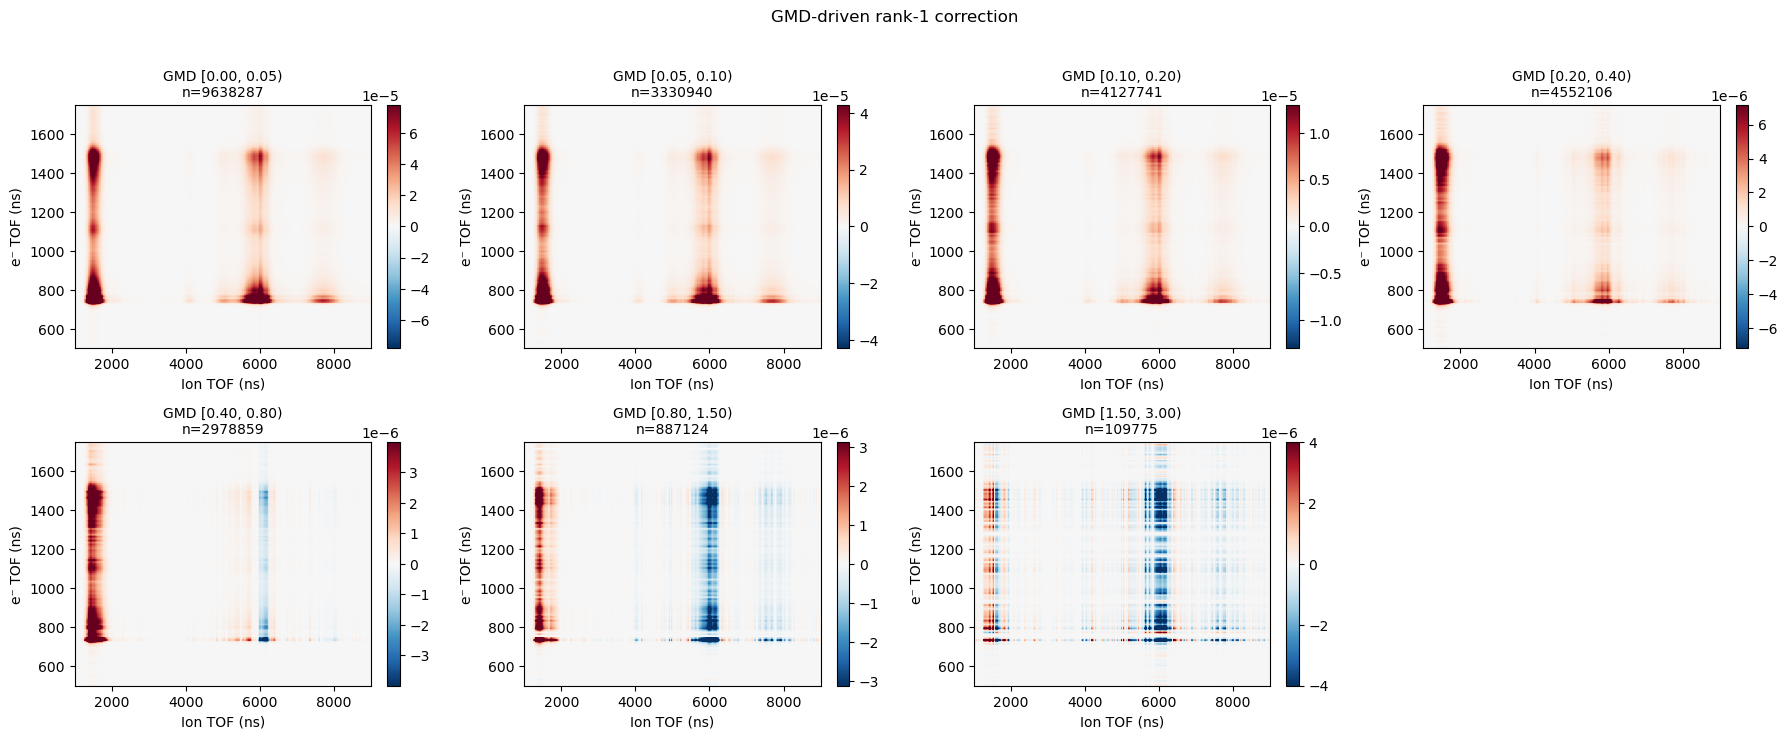

In [7]:
_plot_cov_grid(correction, "GMD-driven rank-1 correction")